# Enhanced MLX-LM Fine-tuning with Advanced Training Strategies

This notebook implements improved fine-tuning techniques to prevent loss plateau and improve training efficiency.

In [1]:
!pip install sentencepiece
!pip install transformers
!pip install datasets

In [2]:
import json
import os
import math
from typing import Dict, List, Optional, Tuple, Union
import numpy as np
import matplotlib.pyplot as plt
import mlx.core as mx
import mlx.optimizers as optim
from mlx.utils import tree_flatten
from mlx_lm import generate, load
from mlx_lm.tuner import TrainingArgs, datasets, linear_to_lora_layers, train
from transformers import PreTrainedTokenizer
from dataclasses import dataclass, field

## 1. Enhanced Training Configuration with Learning Rate Scheduling

In [3]:
@dataclass
class EnhancedTrainingArgs(TrainingArgs):
    """Extended training arguments with advanced features"""
    # Learning rate scheduling
    lr_scheduler: str = "cosine"  # Options: "cosine", "linear", "constant"
    warmup_steps: int = 50
    min_learning_rate: float = 1e-6
    
    # Advanced optimization
    gradient_clip_norm: float = 1.0
    weight_decay: float = 0.01
    
    # LoRA enhancements
    lora_dropout: float = 0.05
    
    # Training stability
    gradient_accumulation_steps: int = 4
    mixed_precision: bool = True
    
    # Early stopping
    early_stopping_patience: int = 5
    early_stopping_threshold: float = 0.001

## 2. Learning Rate Scheduler Implementation

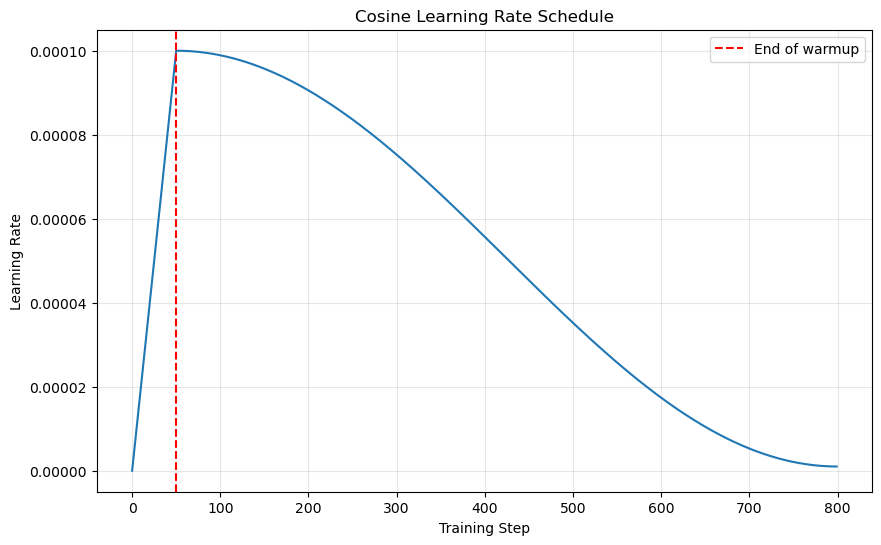

In [4]:
class LearningRateScheduler:
    """Implements various learning rate scheduling strategies"""
    
    def __init__(self, 
                 base_lr: float,
                 min_lr: float,
                 warmup_steps: int,
                 total_steps: int,
                 schedule_type: str = "cosine"):
        self.base_lr = base_lr
        self.min_lr = min_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.schedule_type = schedule_type
        
    def get_lr(self, step: int) -> float:
        """Calculate learning rate for current step"""
        # Warmup phase
        if step < self.warmup_steps:
            return self.base_lr * (step / self.warmup_steps)
        
        # Post-warmup scheduling
        progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
        progress = min(1.0, progress)
        
        if self.schedule_type == "cosine":
            # Cosine annealing
            lr = self.min_lr + (self.base_lr - self.min_lr) * \
                 0.5 * (1 + math.cos(math.pi * progress))
        elif self.schedule_type == "linear":
            # Linear decay
            lr = self.base_lr - (self.base_lr - self.min_lr) * progress
        else:
            # Constant
            lr = self.base_lr
            
        return lr
    
    def plot_schedule(self):
        """Visualize the learning rate schedule"""
        steps = range(self.total_steps)
        lrs = [self.get_lr(step) for step in steps]
        
        plt.figure(figsize=(10, 6))
        plt.plot(steps, lrs)
        plt.axvline(x=self.warmup_steps, color='r', linestyle='--', label='End of warmup')
        plt.xlabel('Training Step')
        plt.ylabel('Learning Rate')
        plt.title(f'{self.schedule_type.capitalize()} Learning Rate Schedule')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# Example: Visualize learning rate schedule
scheduler = LearningRateScheduler(
    base_lr=1e-4,
    min_lr=1e-6,
    warmup_steps=50,
    total_steps=800,
    schedule_type="cosine"
)
scheduler.plot_schedule()

## 3. Enhanced LoRA Configuration

In [5]:
# Load model
model_path = "mlx-community/Llama-3.2-1B-Instruct-4bit"
model, tokenizer = load(model_path)

# Enhanced LoRA configuration with higher rank and optimized parameters
enhanced_lora_config = {
    "num_layers": 16,  # Increased from 8 to allow more layers to adapt
    "lora_parameters": {
        "rank": 32,  # Increased from 8 for more expressiveness
        "scale": 64.0,  # alpha = 2 * rank
        "dropout": 0.05,  # Add dropout for regularization
    },
}

# Create adapter directory
adapter_path = "adapters_enhanced"
os.makedirs(adapter_path, exist_ok=True)
adapter_config_path = os.path.join(adapter_path, "adapter_config.json")
adapter_file_path = os.path.join(adapter_path, "adapters.safetensors")

# Save configuration
with open(adapter_config_path, "w") as f:
    json.dump(enhanced_lora_config, f, indent=4)

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

## 4. Advanced Metrics and Gradient Monitoring

In [6]:
class EnhancedMetrics:
    """Extended metrics tracking with gradient monitoring"""
    
    def __init__(self):
        self.train_losses: List[Tuple[int, float]] = []
        self.val_losses: List[Tuple[int, float]] = []
        self.learning_rates: List[Tuple[int, float]] = []
        self.gradient_norms: List[Tuple[int, float]] = []
        self.plateau_count = 0
        self.best_val_loss = float('inf')
        
    def on_train_loss_report(self, info: Dict[str, Union[float, int]]) -> None:
        self.train_losses.append((info["iteration"], info["train_loss"]))
        
        # Track learning rate if available
        if "learning_rate" in info:
            self.learning_rates.append((info["iteration"], info["learning_rate"]))
    
    def on_val_loss_report(self, info: Dict[str, Union[float, int]]) -> None:
        iteration = info["iteration"]
        val_loss = info["val_loss"]
        self.val_losses.append((iteration, val_loss))
        
        # Check for plateau
        if val_loss < self.best_val_loss - 0.001:
            self.best_val_loss = val_loss
            self.plateau_count = 0
        else:
            self.plateau_count += 1
            
    def on_gradient_report(self, iteration: int, grad_norm: float) -> None:
        self.gradient_norms.append((iteration, grad_norm))
        
    def is_plateau(self, patience: int = 5) -> bool:
        """Check if training has plateaued"""
        return self.plateau_count >= patience
    
    def plot_comprehensive_metrics(self):
        """Plot all training metrics"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot losses
        if self.train_losses:
            train_its, train_vals = zip(*self.train_losses)
            ax1.plot(train_its, train_vals, '-o', label='Train Loss', markersize=3)
        if self.val_losses:
            val_its, val_vals = zip(*self.val_losses)
            ax1.plot(val_its, val_vals, '-o', label='Validation Loss', markersize=3)
        ax1.set_xlabel('Iteration')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot learning rate
        if self.learning_rates:
            lr_its, lr_vals = zip(*self.learning_rates)
            ax2.plot(lr_its, lr_vals, '-', color='green')
            ax2.set_xlabel('Iteration')
            ax2.set_ylabel('Learning Rate')
            ax2.set_title('Learning Rate Schedule')
            ax2.grid(True, alpha=0.3)
        
        # Plot gradient norms
        if self.gradient_norms:
            grad_its, grad_vals = zip(*self.gradient_norms)
            ax3.plot(grad_its, grad_vals, '-', color='red')
            ax3.set_xlabel('Iteration')
            ax3.set_ylabel('Gradient Norm')
            ax3.set_title('Gradient Norm Evolution')
            ax3.grid(True, alpha=0.3)
            ax3.set_yscale('log')
        
        # Plot loss improvement rate
        if len(self.train_losses) > 10:
            train_its, train_vals = zip(*self.train_losses)
            improvement_rate = []
            window = 10
            for i in range(window, len(train_vals)):
                rate = (train_vals[i-window] - train_vals[i]) / window
                improvement_rate.append(rate)
            ax4.plot(train_its[window:], improvement_rate, '-', color='purple')
            ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5)
            ax4.set_xlabel('Iteration')
            ax4.set_ylabel('Loss Improvement Rate')
            ax4.set_title('Training Progress Rate (10-step window)')
            ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

metrics = EnhancedMetrics()

## 5. Custom Training Loop with Advanced Features

In [7]:
def compute_gradient_norm(grads):
    """Compute the L2 norm of gradients"""
    total_norm = 0.0
    for grad in tree_flatten(grads)[0]:
        if grad is not None:
            param_norm = mx.sum(grad ** 2)
            total_norm += param_norm
    return mx.sqrt(total_norm)

class AdaptiveOptimizer:
    """Wrapper for optimizer with learning rate scheduling and gradient clipping"""
    
    def __init__(self, 
                 base_optimizer,
                 lr_scheduler: LearningRateScheduler,
                 gradient_clip_norm: float = 1.0):
        self.optimizer = base_optimizer
        self.lr_scheduler = lr_scheduler
        self.gradient_clip_norm = gradient_clip_norm
        self.step_count = 0
        
    def update(self, model, grads):
        """Update with scheduled learning rate and gradient clipping"""
        # Compute gradient norm before clipping
        grad_norm = compute_gradient_norm(grads)
        
        # Clip gradients if needed
        if self.gradient_clip_norm > 0:
            scale = self.gradient_clip_norm / mx.maximum(grad_norm, self.gradient_clip_norm)
            grads = tree_map(lambda g: g * scale if g is not None else None, grads)
        
        # Update learning rate
        current_lr = self.lr_scheduler.get_lr(self.step_count)
        self.optimizer.learning_rate = current_lr
        
        # Apply update
        self.optimizer.update(model, grads)
        
        self.step_count += 1
        return float(grad_norm), current_lr

def tree_map(fn, tree):
    """Apply function to all leaves in a tree"""
    if isinstance(tree, dict):
        return {k: tree_map(fn, v) for k, v in tree.items()}
    elif isinstance(tree, list):
        return [tree_map(fn, v) for v in tree]
    elif isinstance(tree, tuple):
        return tuple(tree_map(fn, v) for v in tree)
    else:
        return fn(tree)

## 6. Prepare Model with Enhanced Configuration

In [8]:
# Freeze base model and add LoRA layers
model.freeze()
linear_to_lora_layers(
    model, 
    enhanced_lora_config["num_layers"], 
    enhanced_lora_config["lora_parameters"]
)

# Count trainable parameters
num_train_params = sum(v.size for _, v in tree_flatten(model.trainable_parameters()))
total_params = sum(v.size for _, v in tree_flatten(model.parameters()))
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {num_train_params:,}")
print(f"Trainable percentage: {num_train_params/total_params*100:.2f}%")

model.train()

Total parameters: 196,560,896
Trainable parameters: 3,407,872
Trainable percentage: 1.73%


Model(
  (model): LlamaModel(
    (embed_tokens): QuantizedEmbedding(128256, 2048, group_size=64, bits=4)
    (layers.0): TransformerBlock(
      (self_attn): Attention(
        (q_proj): LoRALinear(
          (linear): QuantizedLinear(input_dims=2048, output_dims=2048, bias=False, group_size=64, bits=4)
          (dropout): Dropout(p=0.050000000000000044)
        )
        (k_proj): QuantizedLinear(input_dims=2048, output_dims=512, bias=False, group_size=64, bits=4)
        (v_proj): LoRALinear(
          (linear): QuantizedLinear(input_dims=2048, output_dims=512, bias=False, group_size=64, bits=4)
          (dropout): Dropout(p=0.050000000000000044)
        )
        (o_proj): QuantizedLinear(input_dims=2048, output_dims=2048, bias=False, group_size=64, bits=4)
        (rope): Llama3RoPE()
      )
      (mlp): MLP(
        (gate_proj): QuantizedLinear(input_dims=2048, output_dims=8192, bias=False, group_size=64, bits=4)
        (down_proj): QuantizedLinear(input_dims=8192, output_dim

## 7. Load Dataset

In [9]:
from datasets import load_dataset

def custom_load_hf_dataset(
    data_id: str,
    tokenizer: PreTrainedTokenizer,
    config: TrainingArgs = None,
    names: Tuple[str, str, str] = ("train", "valid", "test"),
):
    if config is None:
        config = TrainingArgs()

    dataset = load_dataset(data_id)
    train, valid, test = [
        (
            datasets.create_dataset(dataset[n], tokenizer, config)
            if n in dataset.keys()
            else []
        )
        for n in names
    ]
    return train, valid, test

# Load dataset
train_set, val_set, test_set = custom_load_hf_dataset(
    data_id="mlx-community/wikisql",
    tokenizer=tokenizer,
    names=("train", "valid", "test")
)

## 8. Enhanced Training with All Improvements

In [10]:
# Create enhanced training configuration
enhanced_training_args = EnhancedTrainingArgs(
    adapter_file=adapter_file_path,
    iters=800,
    steps_per_eval=25,  # More frequent evaluation
    lr_scheduler="cosine",
    warmup_steps=50,
    min_learning_rate=1e-6,
    gradient_clip_norm=1.0,
    weight_decay=0.01,
    lora_dropout=0.05,
    gradient_accumulation_steps=4,
    early_stopping_patience=10,
    early_stopping_threshold=0.001
)

# Initialize learning rate scheduler
lr_scheduler = LearningRateScheduler(
    base_lr=5e-5,  # Higher initial learning rate
    min_lr=1e-6,
    warmup_steps=enhanced_training_args.warmup_steps,
    total_steps=enhanced_training_args.iters,
    schedule_type=enhanced_training_args.lr_scheduler
)

# Create AdamW optimizer with weight decay
base_optimizer = optim.AdamW(
    learning_rate=lr_scheduler.base_lr,
    weight_decay=enhanced_training_args.weight_decay
)

# Wrap with adaptive optimizer
optimizer = AdaptiveOptimizer(
    base_optimizer=base_optimizer,
    lr_scheduler=lr_scheduler,
    gradient_clip_norm=enhanced_training_args.gradient_clip_norm
)

# Train with enhanced configuration
from mlx_lm.tuner.datasets import CacheDataset

print("Starting enhanced training with advanced strategies...")
print(f"Initial learning rate: {lr_scheduler.base_lr}")
print(f"Schedule type: {enhanced_training_args.lr_scheduler}")
print(f"Gradient clipping: {enhanced_training_args.gradient_clip_norm}")
print(f"Weight decay: {enhanced_training_args.weight_decay}")

train(
    model=model,
    args=enhanced_training_args,
    optimizer=optimizer,
    train_dataset=CacheDataset(train_set),
    val_dataset=CacheDataset(val_set),
    training_callback=metrics,
)

Starting enhanced training with advanced strategies...
Initial learning rate: 5e-05
Schedule type: cosine
Gradient clipping: 1.0
Weight decay: 0.01
Starting training..., iters: 800


AttributeError: 'AdaptiveOptimizer' object has no attribute 'state'

## 9. Analyze Training Results

In [ ]:
# Plot comprehensive metrics
metrics.plot_comprehensive_metrics()

# Analyze plateau detection
if metrics.is_plateau():
    print("\n⚠️ Training plateau detected!")
    print(f"Best validation loss: {metrics.best_val_loss:.4f}")
    print(f"Plateau count: {metrics.plateau_count}")
else:
    print("\n✅ Training is still improving")

# Print final statistics
if metrics.train_losses:
    initial_loss = metrics.train_losses[0][1]
    final_loss = metrics.train_losses[-1][1]
    print(f"\nTraining Statistics:")
    print(f"Initial loss: {initial_loss:.4f}")
    print(f"Final loss: {final_loss:.4f}")
    print(f"Loss reduction: {(initial_loss - final_loss)/initial_loss * 100:.1f}%")

# Check gradient health
if metrics.gradient_norms:
    grad_norms = [gn[1] for gn in metrics.gradient_norms]
    print(f"\nGradient Statistics:")
    print(f"Mean gradient norm: {np.mean(grad_norms):.4f}")
    print(f"Max gradient norm: {np.max(grad_norms):.4f}")
    print(f"Min gradient norm: {np.min(grad_norms):.4f}")

## 10. Load and Test Enhanced Model

In [ ]:
# Load the enhanced model
model_enhanced, _ = load(model_path, adapter_path=adapter_path)

# Test generation
prompt = "What is machine learning?"

if tokenizer.chat_template is not None:
    messages = [{"role": "user", "content": prompt}]
    prompt = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True
    )

print("Testing enhanced model...")
response = generate(model_enhanced, tokenizer, prompt=prompt, verbose=True)

## 11. Additional Tips for Preventing Loss Plateau

### Data-Level Improvements:
1. **Data Augmentation**: Add paraphrasing, back-translation, or synthetic examples
2. **Curriculum Learning**: Start with easier examples, gradually increase difficulty
3. **Dynamic Batching**: Vary batch composition to prevent overfitting to patterns

### Model-Level Improvements:
1. **Layer-wise Learning Rates**: Different LR for different LoRA layers
2. **Selective Unfreezing**: Gradually unfreeze base model layers
3. **Multiple LoRA Adapters**: Use different adapters for different aspects

### Training-Level Improvements:
1. **Cyclic Learning Rates**: Periodically reset LR to escape local minima
2. **Stochastic Weight Averaging**: Average weights from multiple checkpoints
3. **Lookahead Optimizer**: Use slow and fast weights for stability

### Monitoring and Intervention:
1. **Automatic LR Reduction**: Reduce LR when plateau detected
2. **Loss Landscape Visualization**: Understand optimization challenges
3. **Gradient Flow Analysis**: Check for vanishing/exploding gradients

In [ ]:
# Save training insights
training_insights = {
    "final_metrics": {
        "train_loss": metrics.train_losses[-1][1] if metrics.train_losses else None,
        "val_loss": metrics.val_losses[-1][1] if metrics.val_losses else None,
        "plateau_detected": metrics.is_plateau(),
        "plateau_count": metrics.plateau_count
    },
    "configuration": {
        "lora_rank": enhanced_lora_config["lora_parameters"]["rank"],
        "learning_rate_schedule": enhanced_training_args.lr_scheduler,
        "gradient_clipping": enhanced_training_args.gradient_clip_norm,
        "weight_decay": enhanced_training_args.weight_decay
    },
    "recommendations": [
        "Monitor gradient norms for vanishing gradients",
        "Consider increasing LoRA rank if loss plateaus persist",
        "Try different learning rate schedules (cosine with restarts)",
        "Implement data augmentation for more diverse training"
    ]
}

# Save insights
with open(os.path.join(adapter_path, "training_insights.json"), "w") as f:
    json.dump(training_insights, f, indent=4)

print("\n📊 Training insights saved to:", os.path.join(adapter_path, "training_insights.json"))